In [1]:
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import pandas as pd
from torch import nn
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from peft import get_peft_model, LoraConfig, TaskType
import pandas as pd
import nltk

2026-02-05 14:00:26.618861: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770300026.821463      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770300026.880501      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770300027.394007      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770300027.394050      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770300027.394053      55 computation_placer.cc:177] computation placer alr

In [2]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
df_train = pd.read_csv('/kaggle/input/dravidianlangtech2026/PS_train.csv')
df_dev = pd.read_csv('/kaggle/input/dravidianlangtech2026/PS_dev.csv')
df_test = pd.read_csv('/kaggle/input/dravidianlangtech2026/PS_test_without_labels.csv')

In [4]:
df_train.head()

,content,labels
0,தென்காசி தொகுதி புதிய தமிழகம் கட்சி வேட்பாளர் ...,Neutral
1,அண்ணன் இதனை சூசகமாக 11 மாதங்கள் முன்பே பேட்டிய...,Substantiated
2,ஒரு வருடம் ஆகி விட்டது இந்த துயரம் நேர்ந்து......,Opinionated
3,"எடப்பாடியை கண்டுகொள்ளாத ""எடப்பாடி""🫢\n ---\nஆதர...",Positive
4,எங்களின் அரசியல் அடுத்த தலைமுறைக்குமானது \n#மக...,Opinionated


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4352 entries, 0 to 4351
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  4352 non-null   object
 1   labels   4352 non-null   object
dtypes: object(2)
memory usage: 68.1+ KB


In [6]:
df_train.describe()

,content,labels
count,4352,4352
unique,4181,7
top,🎙️நமது சின்னம் ஒலிவாங்கி🎙️\n\n#மக்களின்_சின்னம...,Opinionated
freq,11,1361


In [7]:
df_train['labels'].value_counts()

labels
Opinionated          1361
Sarcastic             790
Neutral               637
Positive              575
Substantiated         412
Negative              406
None of the above     171
Name: count, dtype: int64

In [8]:
df_train['labels'].describe()

count            4352
unique              7
top       Opinionated
freq             1361
Name: labels, dtype: object

#Data Analysis

Text(0.5, 1.0, 'Frequency of Classes')

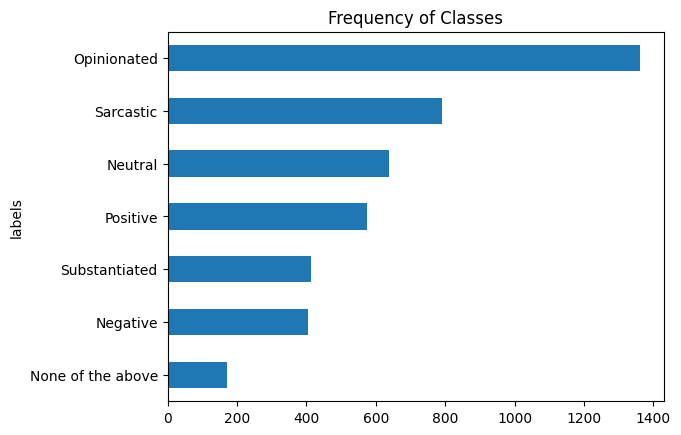

In [9]:
import matplotlib.pyplot as plt
label_counts = df_train['labels'].value_counts(ascending= True)
label_counts.plot.barh()
plt.title('Frequency of Classes')

In [10]:
df_train['Words per content'] = df_train['content'].apply(lambda x : len(nltk.word_tokenize(x)))

<Axes: title={'center': 'Words per content'}, xlabel='labels'>

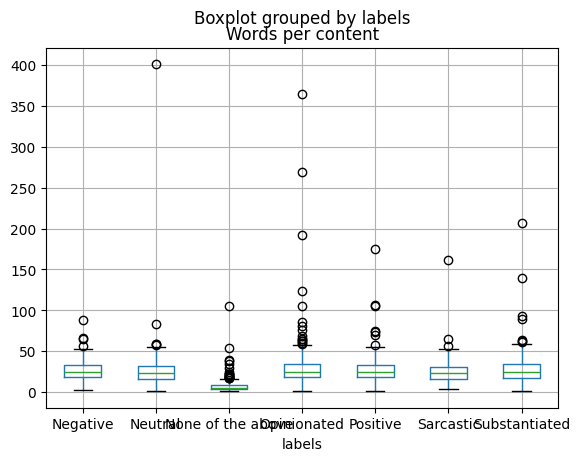

In [11]:
df_train.boxplot("Words per content", by= 'labels')

In [12]:

!pip install emoji indic-nlp-library evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00


In [13]:
import re
import emoji
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory

factory = IndicNormalizerFactory()
normalizer = factory.get_normalizer("ta") 

def preprocess_text_v2(text):
    text = emoji.demojize(text, delimiters=(" :", ": "))
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\u0B80-\u0BFFa-zA-Z0-9\s.,!?:;_"\'()%-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [14]:
df_train['clean_text'] = df_train['content'].apply(preprocess_text_v2)
df_dev['clean_text'] = df_dev['content'].apply(preprocess_text_v2)
df_test['clean_text'] = df_test['content'].apply(preprocess_text_v2)

In [15]:
from imblearn.over_sampling import RandomOverSampler
X_indices = df_train.index.values.reshape(-1, 1)
y_labels = df_train['labels'].values
ros = RandomOverSampler(random_state=42, sampling_strategy='auto')
X_resampled, y_resampled = ros.fit_resample(X_indices, y_labels)
balanced_train_df = df_train.iloc[X_resampled.flatten()].reset_index(drop=True)

In [16]:
from transformers import AutoTokenizer
model_ckpt = "xlm-roberta-base"
tokenizer= AutoTokenizer.from_pretrained(model_ckpt)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

#Data Loader and Train Test Split

In [17]:
from datasets import Dataset, DatasetDict

In [18]:
dataset = DatasetDict(
    {'train':Dataset.from_pandas(balanced_train_df, preserve_index= False),
    'test':Dataset.from_pandas(df_test, preserve_index= False),
    'validation':Dataset.from_pandas(df_dev, preserve_index= False)}
)
dataset

DatasetDict({
    train: Dataset({
        features: ['content', 'labels', 'Words per content', 'clean_text'],
        num_rows: 9527
    })
    test: Dataset({
        features: ['content', 'clean_text'],
        num_rows: 544
    })
    validation: Dataset({
        features: ['content', 'labels', 'clean_text'],
        num_rows: 544
    })
})

In [19]:
def tokenize(batch):
  temp = tokenizer(batch['content'], padding= True, truncation= True, max_length=128)
  return temp


In [20]:
encoded = dataset.map(tokenize, batched= True, batch_size= None)

Map:   0%|          | 0/9527 [00:00<?, ? examples/s]

Map:   0%|          | 0/544 [00:00<?, ? examples/s]

Map:   0%|          | 0/544 [00:00<?, ? examples/s]

In [21]:
label_list = ['Neutral' ,'Substantiated', 'Opinionated', 'Positive', 'Sarcastic', 'Negative'
, 'None of the above']

In [22]:
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i:label for i,label in enumerate(label_list)}

In [23]:
def map_labels_to_id(batch):
    batch['labels'] = label2id[batch['labels']]
    return batch

In [24]:
encoded['train'] = encoded['train'].map(map_labels_to_id)
encoded['validation'] = encoded['validation'].map(map_labels_to_id)

Map:   0%|          | 0/9527 [00:00<?, ? examples/s]

Map:   0%|          | 0/544 [00:00<?, ? examples/s]

In [25]:
encoded['train'].set_format("torch", columns=["input_ids", "attention_mask", "labels"])
encoded['validation'].set_format("torch", columns=["input_ids", "attention_mask", "labels"])
encoded['test'].set_format("torch", columns=["input_ids", "attention_mask"])

#Model Building

In [26]:
from transformers import AutoModelForSequenceClassification, AutoConfig
import torch

In [27]:
num_labels= len(label2id)
device =torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = AutoConfig.from_pretrained(model_ckpt, label2id= label2id, id2label=id2label)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, config= config).to(device)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [28]:
model.config

XLMRobertaConfig {
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "Neutral",
    "1": "Substantiated",
    "2": "Opinionated",
    "3": "Positive",
    "4": "Sarcastic",
    "5": "Negative",
    "6": "None of the above"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "Negative": 5,
    "Neutral": 0,
    "None of the above": 6,
    "Opinionated": 2,
    "Positive": 3,
    "Sarcastic": 4,
    "Substantiated": 1
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.1",
  "type_vocab_size": 1,
  "use_cache"

In [29]:
from transformers import TrainingArguments

In [30]:
batch_size = 32
lr = 2.7929568922612762e-5
weight_d = 0.09380709279499026
training_dir ='muril_base_train_dir'
training_args = TrainingArguments(
    output_dir= training_dir,
    overwrite_output_dir= True,
    num_train_epochs= 6,
    learning_rate = lr,
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size*2,
    gradient_accumulation_steps=2,
    weight_decay = weight_d,
    eval_strategy = 'epoch',
    save_strategy="epoch",
    disable_tqdm= False,
    report_to="none"
)

In [31]:
import evaluate
import numpy as np

accuracy = evaluate.load('accuracy')
def compute_metrics_evaluate(eval_pred):
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis= 1)
  return accuracy.compute(predictions= predictions, references= labels)

In [36]:
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=1)
    
    # Tính các chỉ số
    macro_f1 = f1_score(labels, predictions, average='macro')
    accuracy = accuracy_score(labels, predictions)
    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1  
    }

hyperparameter

In [57]:
from transformers import set_seed
SEED_VALUE = 42
set_seed(SEED_VALUE)

In [44]:
import shutil
import os
import gc
import torch
import optuna
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification
from peft import get_peft_model, LoraConfig, TaskType


gc.collect()
torch.cuda.empty_cache()

def my_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-4, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 6, 15),
        "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.1),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [32]),
        "adam_beta1": trial.suggest_float("adam_beta1", 0.8, 0.99),
        "adam_epsilon": trial.suggest_float("adam_epsilon", 1e-8, 1e-6, log=True),
    }

training_args = TrainingArguments(
    seed=SEED_VALUE,      
    data_seed=SEED_VALUE,
    output_dir="./search_results_lora_temp", 
    eval_strategy="epoch",
    save_strategy="no",        
    load_best_model_at_end=False,  
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    gradient_accumulation_steps=1,
    fp16=True,
    disable_tqdm=False,
    report_to="none",
    optim="adamw_torch",  
)

def model_init():
    model = AutoModelForSequenceClassification.from_pretrained(
        "xlm-roberta-base", num_labels=7, return_dict=True
    )
    peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        r=16,
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=["query", "value"] 
    )

    model = get_peft_model(model, peft_config)
    return model

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("🔍 Đang chạy tìm kiếm Hyperparameter cho LoRA với AdamW...")
best_run = trainer.hyperparameter_search(
    direction="maximize",
    hp_space=my_hp_space,
    n_trials=10,  
    backend="optuna"
)

print("\n" + "="*30)
print("KẾT QUẢ TÌM KIẾM TỐT NHẤT (LORA)")
print("="*30)
print(f"📌 Best Run ID: {best_run.run_id}")
print(f"📌 Best F1 Score: {best_run.objective}")
print("📌 THAM SỐ CẦN GHI LẠI:")
for k, v in best_run.hyperparameters.items():
    print(f"   - {k}: {v}")
print("="*30)

# Dọn dẹp thư mục tạm
if os.path.exists("./search_results_lora_temp"):
    shutil.rmtree("./search_results_lora_temp")

/tmp/ipykernel_55/3955833440.py:53: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2026-02-05 15:16:13,271] A new study created in memory with name: no-name-32549b49-9a72-425a-a711-bac5116acb0c
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able 

🔍 Đang chạy tìm kiếm Hyperparameter cho LoRA với AdamW...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.740601,0.194853,0.175207
2,No log,1.661124,0.329044,0.351287
3,No log,1.625718,0.354779,0.398469
4,1.568900,1.683927,0.286765,0.349928
5,1.568900,1.704607,0.321691,0.362720
6,1.568900,1.707284,0.323529,0.370016
7,1.318700,1.789580,0.340074,0.374751
8,1.318700,1.884571,0.290441,0.349536
9,1.318700,1.907828,0.319853,0.373635
10,1.318700,1.932301,0.358456,0.397770


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.728996,0.261029,0.241853
2,No log,1.721621,0.257353,0.288165


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
[I 2026-02-05 17:42:25,770] Trial 8 pruned. 
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.751932,0.248162,0.221669
2,No log,1.711719,0.305147,0.324892
3,No log,1.669507,0.319853,0.326573


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
[I 2026-02-05 17:47:59,441] Trial 9 pruned. 



KẾT QUẢ TÌM KIẾM TỐT NHẤT (LORA)
📌 Best Run ID: 0
📌 Best F1 Score: 0.7559444498062434
📌 THAM SỐ CẦN GHI LẠI:
   - learning_rate: 0.000416518377704813
   - num_train_epochs: 17
   - weight_decay: 0.056194361585127264
   - per_device_train_batch_size: 32
   - adam_beta1: 0.8248433777037623
   - adam_epsilon: 6.977740005470223e-08


In [ ]:

if os.path.exists("./search_results_temp"):
    shutil.rmtree("./search_results_temp")
    print("✅ Đã xóa sạch thư mục tạm.")

#Build Model and Trainer

In [69]:
from transformers import Trainer

In [71]:
model = AutoModelForSequenceClassification.from_pretrained(
        "xlm-roberta-base", num_labels=7, return_dict=True
    )
peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        r=16,
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=["query", "value"] 
    )

model = get_peft_model(model, peft_config)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [72]:

best_params = {
    "learning_rate": 0.00013142284004666528,        
    "num_train_epochs": 10,     
    "weight_decay": 0.0983991327554873,          
    "adam_beta1": 0.8142790691279208,           
    "adam_epsilon":  6.339871072497331e-08        
}


final_args = TrainingArguments(
    output_dir="./final_model_lora_best",
    learning_rate=best_params["learning_rate"],
    num_train_epochs=best_params["num_train_epochs"],
    weight_decay=best_params["weight_decay"],
    adam_beta1=best_params["adam_beta1"],
    adam_epsilon=best_params["adam_epsilon"],
    per_device_train_batch_size=32,  
    seed=SEED_VALUE, 
    data_seed=SEED_VALUE,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,     
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=1,            
    gradient_accumulation_steps=1,
    fp16=True,
    optim="adamw_torch",
    report_to="none"
)

final_trainer = Trainer(
    model=model,  
    args=final_args,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/tmp/ipykernel_55/1532029260.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(


In [74]:
final_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.737433,0.242647,0.174244
2,No log,1.741096,0.277574,0.286366
3,No log,1.694037,0.321691,0.313728
4,1.640900,1.747756,0.224265,0.273772
5,1.640900,1.648194,0.349265,0.362379
6,1.640900,1.653057,0.332721,0.373165
7,1.499700,1.666568,0.329044,0.348398
8,1.499700,1.685822,0.306985,0.336836
9,1.499700,1.673088,0.332721,0.338689
10,1.499700,1.669683,0.330882,0.350053


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

TrainOutput(global_step=1490, training_loss=1.5276796072121435, metrics={'train_runtime': 1111.603, 'train_samples_per_second': 85.705, 'train_steps_per_second': 1.34, 'total_flos': 6353690671856640.0, 'train_loss': 1.5276796072121435, 'epoch': 10.0})